## **Seção 5 — Modelos auto-regressivos com RNNs**

### **Importações**

In [1]:

import os                                           # módulo para interagir com o sistema de arquivos (criar pastas, ler arquivos, etc.)
import json                                         # para carregar e salvar dados em formato JSON
import re                                           # expressões regulares para manipulação e validação de strings
import string                                       # utilitários para strings (como lista de pontuações, letras, etc.)
from collections import Counter                     # estrutura de dados para contagem rápida de itens
import numpy as np                                  # biblioteca para cálculo numérico e operações com arrays
import torch                                        # PyTorch: framework de aprendizado profundo
import torch.nn as nn                               # módulos de construção de redes neurais (camadas, funções de perda, etc.)
from torch.utils.data import Dataset, DataLoader    # abstrações para datasets e carregamento de dados (batching, shuffle)
import torch.nn.functional as F                     # funções de ativação, perda e utilitários funcionais
from torchinfo import summary                       # para exibir o resumo ("summary") da arquitetura do modelo em PyTorch
from tqdm.auto import tqdm                          # barra de progresso adaptada ao ambiente (notebook/terminal) para loops longos
from torch.utils.data import random_split           # utilitário para dividir um Dataset em subconjuntos (ex.: treinamento/teste)
import matplotlib.pyplot as plt                     # biblioteca para gerar gráficos (ex.: curva de perda por época)
import gdown                                        # utilitário para baixar arquivos do Google Drive via link público
from pathlib import Path                            # para manipulação de caminhos de arquivos

/Users/gilcesarf/git/repositories/imd/imd3004-202602/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Hiperparametros e outras constantes do laboratório

In [50]:
SEED          = 42      # Semente para garantir a reprodutibilidade dos resultados
VOCAB_SIZE    = 10_000  # tamanho máximo do vocabulário (número de tokens distintos considerados)
MAX_LEN       = 200     # comprimento máximo de cada sequência de entrada (número de tokens)
EMBEDDING_DIM = 100     # dimensão dos vetores de embedding que representam cada token
N_UNITS       = 128     # número de unidades (neurônios) na camada recorrente (LSTM/GRU/RNN)
BATCH_SIZE    = 32      # tamanho do lote (batch) usado em cada atualização de gradiente
EPOCHS        = 25      # número de épocas de treinamento (passadas completas pelo conjunto de treino)
LEARNING_RATE = 1e-3    # taxa de aprendizado do otimizador (passo de atualização dos parâmetros)

### Definição do dispositivo de computação

In [49]:

DEVICE = ( # dispositivo de computação: tipo de acelerador (GPU/MPS) se disponível, caso contrário "cpu"
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

### Download dos dados

In [3]:
url = 'https://drive.google.com/file/d/1gzDjjou1lbCU87H_rDg5mhAJlkqTTqgn/view?usp=sharing'  # URL pública do arquivo no Google Drive
os.makedirs("data/", exist_ok=True)
output = 'data/full_format_recipes.json'                                                    # nome do arquivo local onde o JSON será salvo
if not os.path.isfile(output):                                                              # verifica se o arquivo ainda não existe no diretório atual
    print(f"Arquivo '{output}' não encontrado. Fazendo download...")                        # informa que o download será realizado
    gdown.download(
        url=url, 
        output=output, 
        quiet=False, 
    )                         # baixa o arquivo do Google Drive para o caminho especificado
else:
    print(f"Arquivo '{output}' já existe. Pulando download.")                               # informa que o arquivo já existe e evita novo download

with open(output) as json_data:           # abre o arquivo JSON de receitas em modo leitura
    recipe_data = json.load(json_data)    # carrega o conteúdo do arquivo como uma lista de dicionários


Arquivo 'data/full_format_recipes.json' já existe. Pulando download.


### Limpeza e preparação do dataset

#### Filtra apenas os dados que possuem os campos `title` e `directions` diferente de vazio.

In [4]:
filtered_data = [                                                   # lista de strings (uma por receita) que será usada como corpus de texto
    "Recipe for " + x["title"] + " | " + " ".join(x["directions"])  # monta um texto único: título + '|' + instruções concatenadas
    for x in recipe_data                                            # percorre cada dicionário de receita carregado do JSON original
    if "title" in x                                                 # garante que a chave "title" existe no dicionário
    and x["title"] is not None                                      # garante que o título não é nulo
    and "directions" in x                                           # garante que a chave "directions" existe no dicionário
    and x["directions"] is not None                                 # garante que as instruções não são nulas
]

#### Criação da Classe EpicuriousRecipesDataset

In [5]:
class EpicuriousRecipesDataset(Dataset):
    """
    Dataset de receitas do Epicurious para modelagem auto-regressiva.

    Esta classe:
    - normaliza e tokeniza textos de receitas (título + instruções),
    - constrói um vocabulário limitado ao `vocab_size` mais frequentes,
    - codifica cada texto como uma sequência fixa de IDs (com padding/truncamento),
    - fornece pares (x, y) para treinamento auto-regressivo, com y deslocado em 1 token.

    Parameters
    ----------
    texts : list of str
        Lista de textos brutos de entrada (uma string por receita).
    vocab_size : int, optional
        Tamanho máximo do vocabulário (incluindo os tokens especiais) (default = 10_000).
    max_len : int, optional
        Comprimento máximo das sequências (em tokens) usado para cada exemplo (default = 200).

    Attributes
    ----------
    max_len : int
        Comprimento máximo das sequências (sem contar o deslocamento extra, internamente usa max_len + 1).
    pad_id : int
        Índice reservado para o token de padding ``<PAD>``.
    unk_id : int
        Índice reservado para o token desconhecido ``<UNK>``.
    cleaned : list of str
        Lista de textos após normalização (pontuação separada e minúsculas).
    itos : list of str
        Vocabulário na ordem índice → token (index-to-string).
    stoi : dict
        Dicionário de token → índice (string-to-index).
    data : list of torch.Tensor
        Lista de tensores de inteiros com IDs de tokens, já com padding/truncamento aplicado.
    """
    def __init__(self, texts, vocab_size=10_000, max_len=200):
        """
        Inicializa o dataset de receitas para modelagem auto-regressiva.

        Parameters
        ----------
        texts : list of str
            Lista de textos brutos (uma string por receita), tipicamente "título | instruções".
        vocab_size : int, optional
            Tamanho máximo do vocabulário, incluindo os tokens especiais <PAD> e <UNK> (default = 10_000).
        max_len : int, optional
            Comprimento máximo da sequência de entrada (em tokens) usada por exemplo; internamente
            é construída uma sequência de tamanho ``max_len + 1`` para formar os pares (x, y) (default = 200).

            Exemplo
            -------
            Suponha `max_len = 4`. Depois de tokenizar/pad/truncar, para uma receita
            temos internamente uma sequência de 5 tokens:

                seq = [t0, t1, t2, t3, t4]  (tamanho = max_len + 1 = 5)

            A partir dela, construímos:

                x = seq[:-1] = [t0, t1, t2, t3]  (tamanho = max_len = 4)
                y = seq[1:]  = [t1, t2, t3, t4]  (tamanho = max_len = 4)

            Ou seja, para treinamento do modelo auto-regressivo, cada exemplo é um par:

                entrada: (x(0), x(1), ..., x(max_len - 1)) = (t0, t1, t2, t3)
                alvo:    (x(1), x(2), ..., x(max_len))     = (t1, t2, t3, t4)

        """

        self.cleaned = [self._pad_punct(text) for text in texts]         # gera lista de textos normalizados (minúsculas, pontuação e espaços tratados)

        # construção do vocabulário
        self.itos, self.stoi = self._build_vocab(self.cleaned,           # constrói o vocabulário a partir dos textos normalizados, retornando mapeamentos índice→token (itos) e token→índice (stoi)
                                                vocab_size,
                                                pad_token="<PAD>",
                                                unk_token="<UNK>")
        self.pad_id = self.stoi["<PAD>"]                                # índice (= 0) reservado para o token de padding <PAD> (usado para preencher sequências curtas até o comprimento fixo)
        self.unk_id = self.stoi["<UNK>"]                                # índice (= 1) reservado para o token desconhecido <UNK> ( usado quando um token não existe no vocabulário aprendido)

        self.max_len = max_len                                          # comprimento máximo da sequência (número de tokens considerados por exemplo)
        self.data = self._encode_and_pad()                              # codifica textos normalizados em IDs e aplica padding/truncamento para max_len + 1

    @staticmethod
    def _pad_punct(s: str) -> str:
        """
        Normaliza uma string (letras minúsculas, tratamento sistemático da pontuação e de espaços).

        Parameters
        ----------
        s : str
            String a ser normalizada.

        Returns
        -------
        str
            String normalizada.
        """
        s = re.sub(f"([{re.escape(string.punctuation)}])", r" \1 ", s)  # insere espaço ao redor de cada sinal de pontuação
        s = re.sub(" +", " ", s).lower()                                # reduz múltiplos espaços a um único espaço e converte todas as letras para minúsculas
        return s

    @staticmethod
    def _build_vocab(cleaned_texts, vocab_size, pad_token="<PAD>", unk_token="<UNK>"):
        """
        Constrói o vocabulário a partir de uma lista de textos normalizados.

        Parameters
        ----------
        cleaned_texts : list of str
            Lista de strings normalizadas.
        vocab_size : int
            Tamanho máximo do vocabulário (incluindo tokens especiais).
        pad_token : str, optional
            Token especial usado para padding (default = "<PAD>").
        unk_token : str, optional
            Token especial usado para tokens desconhecidos (default = "<UNK>").

        Returns
        -------
        itos : list of str
            Lista de tokens na ordem índice → token.
        stoi : dict
            Dicionário token → índice.
        """

        # contabiliza a frequência global de cada token no corpus
        counter = Counter()                                             # contador de frequência de tokens no corpus
        for text in cleaned_texts:                                      # percorre cada texto normalizado
            counter.update(text.split())                                # atualiza o contador com os tokens desse texto

        # seleciona os tokens mais comuns, reservando 2 posições para pad_token e unk_token
        most_common = counter.most_common(vocab_size - 2)               # pega os (vocab_size-2) tokens mais frequentes

        # lista que mapeia índice -> token
        itos = [pad_token, unk_token] + [w for w, _ in most_common]     # cria lista de tokens na ordem dos índices

        # dicionário que mapeia token -> índice
        stoi = {w: i for i, w in enumerate(itos)}                       # cria mapeamento inverso de token para índice

        return itos, stoi

    def _encode_and_pad(self):
            """
            Converte os textos normalizados em sequências de IDs com tamanho fixo (max_len + 1).

            Usa:
            - self.cleaned : lista de textos normalizados;
            - self.stoi    : dicionário token → índice;
            - self.pad_id  : índice do token <PAD>;
            - self.unk_id  : índice do token <UNK>;
            - self.max_len : comprimento máximo da sequência de entrada.

            Returns
            -------
            list of torch.Tensor
                Lista de tensores de inteiros com IDs de tokens,
                todos com comprimento ``self.max_len + 1``.
            """

            data = []                                                           # lista que armazenará as sequências tokenizadas como tensores

            for text in self.cleaned:                                           # percorre cada texto normalizado

                tokens = text.split()                                           # divide o texto em tokens por espaço

                ids = [self.stoi.get(t, self.unk_id) for t in tokens]           # converte tokens em IDs, usando unk_id quando token não está no vocabulário

                if len(ids) < (self.max_len + 1):                               # verifica se a sequência é menor que o tamanho desejado (max_len + 1)
                    ids += [self.pad_id] * ((self.max_len + 1) - len(ids))      # se a sequência for curta, completa a sequência com <PAD> até o comprimento fixo (max_len + 1)
                else:
                    ids = ids[: (self.max_len + 1)]                             # se a sequência for longa, recorta a sequência para o tamanho máximo permitido (max_len + 1 )

                data.append(torch.tensor(ids, dtype=torch.long))                # converte a sequência para tensor de inteiros (IDs de tokens) e adiciona à lista
            return data

    def __len__(self):
        """
        Retorna o número de exemplos disponíveis no dataset.

        Returns
        -------
        int
            Quantidade de sequências armazenadas em ``self.data``.
        """
        return len(self.data)  # número total de exemplos (sequências) no dataset

    def __getitem__(self, idx):
        """
        Retorna o par (x, y) no índice especificado, para treinamento auto-regressivo.

        Para uma sequência interna de tamanho ``max_len + 1``, este método produz:
        - x: tokens de posição 0 até max_len - 1
        - y: tokens de posição 1 até max_len

        Ou seja, y é a mesma sequência de x deslocada em 1 passo para a direita, o que
        permite treinar o modelo a prever o próximo token a cada posição.

        Parameters
        ----------
        idx : int
            Índice do exemplo desejado no dataset.

        Returns
        -------
        x : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens de entrada.
        y : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens-alvo (sequência deslocada).
        """
        seq = self.data[idx]   # sequência completa de IDs para este exemplo (tamanho max_len + 1)
        x = seq[:-1]           # entrada: todos os tokens exceto o último (posição 0 até max_len - 1)
        y = seq[1:]            # alvo: todos os tokens exceto o primeiro (posição 1 até max_len)
        return x, y            # retorna o par (x, y) = (entrada, alvo) para modelagem auto-regressiva


#### Instanciação do Dataset a partir dos dados filtrados

In [6]:
ds = EpicuriousRecipesDataset(
    filtered_data,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN
)

#### Separação dos datasets de treino e teste

In [7]:
N = len(ds)                                                # número total de exemplos disponíveis no dataset completo
N_train = int(0.9 * N)                                     # define 90% dos exemplos para o conjunto de treinamento
N_test  = N - N_train                                      # define os 10% restantes para o conjunto de teste

train_ds, test_ds = random_split(
    dataset=ds,
    lengths=[N_train, N_test],                             # tamanhos desejados para os subconjuntos (treinamento e teste)
    generator=torch.Generator().manual_seed(SEED)          # fixa a semente para obter sempre o mesmo split (reprodutibilidade)
)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # DataLoader de treinamento: agrupa exemplos em lotes e embaralha a cada época
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)  # DataLoader de teste: agrupa exemplos em lotes, mantendo a ordem fixa


### Redes Neurais ( `RNNModel` )

A classe fornecida como exemplo pelo professor no laboratório foi ligeiramente adaptada para permitir instanciação dos três diferentes tipos de camada recorrente: RNN clássica, LSTM e GRU. Dessa forma simplificaremos o loop de treinamento e configuração dos experimentos, permitindo também num único loop de treinamento executar os três experimentos solicitados.

In [8]:
class RNNModel(nn.Module):
    """
    Modelo auto-regressivo baseado em redes neurais recorrentes.

    A arquitetura é composta por:
    1. uma camada de embedding, que transforma índices de tokens em vetores densos;
    2. uma camada recorrente, que pode ser LSTM, GRU ou RNN clássica;
    3. uma camada linear, que projeta os estados ocultos para o vocabulário.

    Parameters
    ----------
    vocab_size : int
        Tamanho do vocabulário.
    embedding_dim : int
        Dimensão dos vetores de embedding.
    hidden_size : int
        Número de unidades da camada recorrente.
    rnn_type : str
        Tipo de camada recorrente utilizada: "lstm", "gru" ou "rnn".
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_size: int,
        rnn_type: str
    ) -> None:

        super().__init__()

        # Camada de embedding: transforma cada índice de token em um vetor
        # denso de dimensão embedding_dim. O índice 0 corresponde ao padding.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Camada recorrente. A arquitetura utilizada é determinada por rnn_type,
        # mantendo os mesmos valores de entrada e hidden_size para permitir uma
        # comparação direta entre LSTM, GRU e RNN clássica.
        if rnn_type == "lstm":

            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                batch_first=True
            )

        elif rnn_type == "gru":

            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                batch_first=True
            )

        elif rnn_type == "rnn":

            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                nonlinearity="tanh",
                batch_first=True
            )

        else:
            raise ValueError(
                f"Tipo de RNN inválido: {rnn_type}. "
                'Use "lstm", "gru" ou "rnn".'
            )

        # Camada linear final: projeta, para cada posição da sequência,
        # o estado oculto produzido pela camada recorrente para o espaço
        # do vocabulário.
        self.fc = nn.Linear(
            in_features=hidden_size,
            out_features=vocab_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Executa a propagação direta do modelo.

        Parameters
        ----------
        x : torch.Tensor
            Tensor contendo índices de tokens com shape (B, S), onde
            B é o tamanho do lote e S é o comprimento da sequência.

        Returns
        -------
        torch.Tensor
            Logits com shape (B, S, V), onde V é o tamanho do vocabulário.
        """

        # Converte os índices dos tokens em embeddings:
        # (B, S) -> (B, S, embedding_dim).
        emb = self.embedding(x)

        # Processa toda a sequência pela camada recorrente.
        # A saída contém um estado oculto para cada posição:
        # (B, S, embedding_dim) -> (B, S, hidden_size).
        #
        # O segundo valor retornado corresponde aos estados finais da camada
        # recorrente e não é necessário para a previsão token a token.
        output, _ = self.rnn(emb)

        # Projeta cada estado oculto para o vocabulário:
        # (B, S, hidden_size) -> (B, S, vocab_size).
        logits = self.fc(output)

        return logits

### Cálculo do negativo da logaritmo da verossimilhança (negative log-likelihood - NLL)

In [9]:
def compute_nll(logits, targets, loss_fn):
    """
    Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL) agregada sobre todos os tokens do batch,
    reformatando logits e alvos para o shape esperado por CrossEntropyLoss.

    Parameters
    ----------
    logits : torch.Tensor
        Tensor de logits com shape [B, L, V], onde:
        B = batch_size, L = comprimento da sequência, V = tamanho do vocabulário.
    targets : torch.Tensor
        Tensor de alvos com shape [B, L], contendo IDs de tokens.
    loss_fn : torch.nn.Module
        Instância de função de perda (ex.: nn.CrossEntropyLoss)

    Returns
    -------
    torch.Tensor
        Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
    """
    B, L, V = logits.shape                          # B: batch_size, L: seq_len, V: vocab_size
    loss = loss_fn(
        logits.view(B * L, V),   # reshape de [B, L, V] -> [N, C], onde:
                                    #   N = B*L (um "exemplo" por token do lote)
                                    #   C = V   (número de classes = tamanho do vocabulário)
                                    # CrossEntropyLoss espera entradas nesse formato [N, C].
        targets.view(B * L)      # reshape de [B, L] -> [N], com:
                                    #   N = B*L (um rótulo inteiro para cada token do lote)
                                    # CrossEntropyLoss espera alvos 1D [N] alinhados com as linhas de input.
    )
    return loss

### Função que executa o treinamento de um modelo específico ( instância de `RNNModel` )

In [10]:
def train_autoregressive_model(model, train_dl):
    """
    Treina um modelo auto-regressivo (LSTM/GRU/RNN clássica) em um DataLoader de pares (x, y).

    Cada exemplo do DataLoader deve ter o formato:
    - x: tensor [B, L] com IDs de tokens de entrada;
    - y: tensor [B, L] com IDs de tokens-alvo, deslocados em 1 passo no tempo
         (ou seja, y contém os "próximos tokens" que o modelo deve prever).

    A função treina o modelo por EPOCHS épocas e devolve, para cada época,
    a perda média de treinamento (NLL média por token não-PAD, de acordo com CrossEntropyLoss).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo recorrente (por exemplo, LSTM, GRU ou RNN clássica) que recebe
        tensores [B, L] e retorna logits [B, L, V], onde V é o tamanho do vocabulário.
    train_dl : torch.utils.data.DataLoader
        DataLoader que produz lotes (x_batch, y_batch) de tensores inteiros com IDs
        de tokens de entrada e de tokens-alvo.

    Returns
    -------
    list of float
        Lista contendo a perda média de treinamento em cada época.
    """

    model.to(DEVICE)                                                        # garante que o modelo está no mesmo dispositivo dos lotes (CPU ou GPU)

    loss_fn = nn.CrossEntropyLoss(ignore_index=0, reduction="mean")         # função de perda: entropia cruzada ignorando o token <PAD> (ID 0) no cálculo da média

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)      # otimizador Adam com taxa de aprendizado definida em LEARNING_RATE

    epoch_losses = []                                                       # lista para armazenar a perda média de cada época


    pbar = tqdm(range(1, EPOCHS + 1), desc="Época", unit="época") # barra de progresso sobre as épocas

    for epoch in pbar:                                      # loop externo sobre as épocas de treinamento

        model.train()                                                       # coloca o modelo em modo de treinamento
        running_loss = 0.0                                                  # acumulador da perda ao longo dos lotes desta época

        for x_batch, y_batch in train_dl:                                   # loop interno sobre os lotes produzidos pelo DataLoader de treino

            x_batch = x_batch.to(DEVICE)                                    # envia o lote de entradas para o dispositivo (forma: [B, L])
            y_batch = y_batch.to(DEVICE)                                    # envia o lote de alvos para o dispositivo (forma: [B, L])

            logits = model(x_batch)                                         # obtém logits do modelo: [B, L, V] (um vetor de logits por token)
            loss = compute_nll(logits, y_batch, loss_fn)                    # calcula a NLL agregada de acordo com o reduction da loss_fn (aqui: média por token não-PAD)
            loss.backward()                                                 # calcula gradientes da loss em relação aos parâmetros do modelo
            optimizer.step()                                                # atualiza os parâmetros do modelo usando os gradientes
            optimizer.zero_grad()                                           # zera gradientes acumulados de iterações anteriores

            running_loss += loss.item()                                     # acumula o valor escalar da perda deste lote

        avg_loss = running_loss / len(train_dl)                             # perda média da época (média das losses de todos os lotes)
        epoch_losses.append(avg_loss)                                       # armazena a perda média desta época

        # print(f"Epoch {epoch:>2}, train loss: {avg_loss:.4f}")              # imprime o progresso do treinamento

        pbar.set_postfix({"função de perda": f"{avg_loss:.4f}"})            # atualiza o texto da barra de progresso com a loss da época

    return epoch_losses                                                     # retorna a lista com a perda média de cada época

### Funções auxiliares

#### Exibição das top K palavras mais prováveis em um passo qualquer

In [11]:
def print_probs_pt(info, itos, top_k=5):
    """
    Mostra, para cada passo de geração, as top_k palavras mais prováveis
    de acordo com o vetor de probabilidades armazenado.

    Parameters
    ----------
    info : list of dict
        Lista retornada por TextGenerator.generate(), onde cada item contém:
        - "prompt": texto gerado até aquele passo;
        - "word_probs": vetor numpy com probabilidades sobre o vocabulário;
        - "selected_idx": índice do token selecionado naquele passo;
        - "selected_word": token selecionado naquele passo.

    itos : list of str
        Lista índice -> token (index-to-string) usada para mapear IDs de volta a palavras.
    top_k : int, optional
        Número de tokens mais prováveis a serem exibidos em cada passo.
        (default = 5)
    """
    for step in info:                                      # percorre cada passo registrado na geração
        prompt = step["prompt"]                            # texto corrente até aquele passo
        word_probs = step["word_probs"]                    # vetor numpy com probabilidade de cada token


        idx_sorted = np.argsort(word_probs)[::-1][:top_k]  # obtém os índices dos top_k tokens mais prováveis (ordem decrescente de probabilidade)
        p_sorted = word_probs[idx_sorted]                  # probabilidades correspondentes aos índices top_k

        print(f"\nPROMPT: {prompt}")
        for idx, p in zip(idx_sorted, p_sorted):           # percorre cada token entre os mais prováveis
            token = itos[idx]                              # converte índice em token de texto
            print(f"{token:<15} {p*100:6.2f}%")            # imprime token justificado e probabilidade em porcentagem
        print("--------\n")                                # separador visual entre passos

#### Cálculo da Perplexidade média por token para um modelo específico ( instância de `RNNModel` )

In [12]:
def compute_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um modelo auto-regressivo em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        Modelo já treinado que recebe tensores [B, L] e retorna logits [B, L, V].
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.CrossEntropyLoss(ignore_index=0,              # entropia cruzada ignorando o token <PAD> (ID 0)
                                  reduction="sum")             # reduction="sum": retorna a soma da NLL sobre os tokens válidos do lote

    with torch.no_grad():                                      # bloco sem cálculo de gradiente (apenas avaliação)
        for x_batch, y_batch in data_loader:                   # percorre todos os lotes (x, y) do data_loader
            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            logits = model(x_batch)                            # obtém logits do modelo: [B, L, V]

            loss = compute_nll(logits, y_batch, loss_fn)       # NLL somada sobre todos os tokens não-PAD do lote (escalares)

            total_loss += loss                                 # acumula a soma das perdas de todos os lotes
            total_tokens += (y_batch != 0).sum()               # acumula quantos tokens não são <PAD> (ID 0) em todo o data_loader

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD em todo o conjunto avaliado
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média por token)

    return avg_nll.item(), ppl.item()                          # devolve valores escalares em float (para impressão / logging)

### Salvamento e Recuperação de Checkpoints

#### Garante que o diretório de checkpoints existe

In [13]:
# Diretório utilizado para armazenar os checkpoints dos modelos treinados.
CHECKPOINT_DIR = Path("checkpoints")

# Cria o diretório e seus diretórios-pai caso ainda não existam.
# O parâmetro exist_ok=True evita erro quando o diretório já existe.
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

#### Retorna o nome do checkpoint conforme o tipo de modelo

In [14]:
def get_rnn_checkpoint_path(rnn_type):
    """
    Retorna o caminho do checkpoint correspondente a um modelo
    recorrente do Laboratório 5.

    Parameters
    ----------
    rnn_type : str
        Tipo da camada recorrente utilizada: "lstm", "gru" ou "rnn".

    Returns
    -------
    pathlib.Path
        Caminho do arquivo utilizado para persistir o checkpoint.
    """

    # Utiliza o identificador do laboratório como prefixo para evitar
    # colisões com checkpoints de experimentos passados ou futuros.
    return CHECKPOINT_DIR / f"lab5-{rnn_type}.pt"

#### Salva um checkpoint

In [15]:
def save_rnn_checkpoint(rnn_type, model, results):
    """
    Salva o estado de um modelo recorrente e os resultados obtidos
    durante seu treinamento e avaliação.

    O checkpoint contém os pesos treinados, os parâmetros necessários
    para reconstruir a arquitetura e as métricas utilizadas nas análises
    posteriores. Os resultados da geração de texto não são armazenados,
    pois podem ser reproduzidos rapidamente a partir do modelo treinado.

    Parameters
    ----------
    rnn_type : str
        Tipo da camada recorrente utilizada: "lstm", "gru" ou "rnn".
    model : torch.nn.Module
        Modelo treinado que será armazenado.
    results : dict
        Resultados obtidos durante o treinamento e a avaliação.
    """

    # Agrupa em um único objeto todas as informações necessárias para
    # reconstruir o modelo e recuperar os resultados do treinamento.
    checkpoint = {

        # Identifica a arquitetura recorrente utilizada.
        "rnn_type": rnn_type,

        # Armazena os hiperparâmetros necessários para reconstruir
        # exatamente a arquitetura do modelo.
        "vocab_size": VOCAB_SIZE,
        "embedding_dim": EMBEDDING_DIM,
        "hidden_size": N_UNITS,

        # Armazena somente os parâmetros aprendidos pelo modelo.
        # O state_dict evita serializar diretamente a implementação
        # completa da classe.
        "model_state_dict": model.state_dict(),

        # Histórico utilizado para reconstruir as curvas de treinamento.
        "losses": results.get("losses"),

        # Métricas calculadas sobre o conjunto de teste.
        "nll": results.get("nll"),
        "ppl": results.get("ppl"),

        # Quantidade de parâmetros treináveis do modelo.
        "num_params": results.get("num_params")
    }

    # Obtém o caminho padronizado do checkpoint do Laboratório 5.
    checkpoint_path = get_rnn_checkpoint_path(rnn_type)

    # Persiste o checkpoint no disco.
    torch.save(
        checkpoint,
        checkpoint_path
    )

    print(f"Checkpoint salvo: {checkpoint_path}")

#### Recupera um checkpoint

In [16]:
def load_rnn_checkpoint(rnn_type):
    """
    Carrega um checkpoint e reconstrói o modelo recorrente correspondente.

    O modelo é inicialmente reconstruído na CPU e, depois que seus pesos
    são restaurados, é movido para o dispositivo configurado no notebook.

    Parameters
    ----------
    rnn_type : str
        Tipo da camada recorrente utilizada: "lstm", "gru" ou "rnn".

    Returns
    -------
    model : RNNModel
        Modelo reconstruído com os pesos obtidos durante o treinamento.
    results : dict
        Resultados armazenados durante o treinamento e a avaliação.
    """

    # Obtém o caminho padronizado do checkpoint do Laboratório 5.
    checkpoint_path = get_rnn_checkpoint_path(rnn_type)

    # Carrega inicialmente o checkpoint na CPU para que o arquivo
    # não dependa do dispositivo utilizado durante o treinamento.
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    # Reconstrói a arquitetura utilizando os mesmos hiperparâmetros
    # registrados quando o modelo foi treinado.
    model = RNNModel(
        vocab_size=checkpoint["vocab_size"],
        embedding_dim=checkpoint["embedding_dim"],
        hidden_size=checkpoint["hidden_size"],
        rnn_type=checkpoint["rnn_type"]
    )

    # Restaura os parâmetros aprendidos durante o treinamento.
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Move o modelo para o dispositivo configurado na execução atual.
    model = model.to(DEVICE)

    # Reconstrói a estrutura esperada pelo restante do notebook.
    results = {
        "model": model,
        "losses": checkpoint["losses"],
        "nll": checkpoint["nll"],
        "ppl": checkpoint["ppl"],
        "num_params": checkpoint["num_params"]
    }

    return model, results

### Execução do treinamento

#### Inicialização de variáveis

In [17]:
# Tipos de redes recorrentes que serão comparados.
RNN_TYPES = ["lstm", "gru", "rnn"]

# Dicionário que concentra os modelos e os resultados produzidos
# por cada uma das arquiteturas recorrentes.
resultados_rnn = {}

#### Treinamento dos modelos

In [18]:
# Executa o mesmo experimento para LSTM, GRU e RNN clássica.
for rnn_type in RNN_TYPES:

    # Obtém o caminho padronizado do checkpoint correspondente
    # ao modelo recorrente atual.
    checkpoint_path = get_rnn_checkpoint_path(rnn_type)

    print("\n" + "=" * 70)
    print(f"MODELO: {rnn_type.upper()}")
    print("=" * 70)

    # Verifica se este experimento já foi executado anteriormente.
    # Quando o checkpoint existe, o treinamento é evitado e os pesos
    # e resultados armazenados são simplesmente restaurados.
    if checkpoint_path.exists():

        print(f"Checkpoint encontrado: {checkpoint_path}")
        print("Carregando modelo treinado...")

        # Reconstrói o modelo e recupera os resultados armazenados
        # durante a execução anterior.
        model, results = load_rnn_checkpoint(
            rnn_type
        )

        # Restaura a mesma estrutura de dados utilizada quando o
        # treinamento é realizado diretamente nesta execução.
        resultados_rnn[rnn_type] = results

        print("Modelo carregado com sucesso.")

    else:

        print("Checkpoint não encontrado.")
        print(f"Treinando modelo {rnn_type.upper()}...")

        # Reinicia a semente imediatamente antes da criação de cada
        # modelo para tornar sua inicialização reproduzível e atender
        # ao requisito de utilizar a mesma semente nos experimentos.
        torch.manual_seed(SEED)

        # Cria uma nova instância utilizando os mesmos hiperparâmetros
        # para todos os experimentos. Apenas o tipo da camada recorrente
        # é alterado entre LSTM, GRU e RNN clássica.
        model = RNNModel(
            vocab_size=VOCAB_SIZE,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=N_UNITS,
            rnn_type=rnn_type
        ).to(DEVICE)

        # Treina o modelo utilizando o mesmo conjunto de treinamento
        # e os mesmos hiperparâmetros definidos para os três experimentos.
        losses = train_autoregressive_model(
            model,
            train_dl
        )

        # Calcula a NLL média e a perplexidade sobre o mesmo conjunto
        # de teste utilizado na avaliação das três arquiteturas.
        test_nll, test_ppl = compute_perplexity(
            model,
            test_dl
        )

        # Conta somente os parâmetros que participam do treinamento.
        # Essa informação também será utilizada posteriormente na
        # comparação com os modelos MiniGPT do Laboratório 6.
        num_params = sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )

        # Armazena em memória o modelo e todos os resultados necessários
        # para reconstruir posteriormente as análises e os gráficos.
        resultados_rnn[rnn_type] = {
            "model": model,
            "losses": losses,
            "nll": test_nll,
            "ppl": test_ppl,
            "num_params": num_params
        }

        # Salva imediatamente o experimento depois que o treinamento
        # e a avaliação terminam. Caso a execução seja interrompida
        # durante outro modelo, este não precisará ser treinado novamente.
        save_rnn_checkpoint(
            rnn_type,
            model,
            resultados_rnn[rnn_type]
        )

    # Recupera os resultados independentemente de terem sido produzidos
    # nesta execução ou restaurados de um checkpoint anterior.
    results = resultados_rnn[rnn_type]

    # Exibe as principais métricas para confirmar o resultado carregado
    # ou recém-calculado para a arquitetura atual.
    print(
        f"\n{rnn_type.upper():4s} | "
        f"NLL: {results['nll']:.4f} | "
        f"PPL: {results['ppl']:.2f} | "
        f"Parâmetros: {results['num_params']:,}"
    )


MODELO: LSTM
Checkpoint não encontrado.
Treinando modelo LSTM...


Época: 100%|██████████| 25/25 [06:30<00:00, 15.61s/época, função de perda=2.1231]


Checkpoint salvo: checkpoints/lab5-lstm.pt

LSTM | NLL: 2.3420 | PPL: 10.40 | Parâmetros: 2,407,760

MODELO: GRU
Checkpoint não encontrado.
Treinando modelo GRU...


Época: 100%|██████████| 25/25 [14:26<00:00, 34.68s/época, função de perda=2.1056]


Checkpoint salvo: checkpoints/lab5-gru.pt

GRU  | NLL: 2.3433 | PPL: 10.42 | Parâmetros: 2,378,320

MODELO: RNN
Checkpoint não encontrado.
Treinando modelo RNN...


Época: 100%|██████████| 25/25 [09:29<00:00, 22.77s/época, função de perda=2.3767]


Checkpoint salvo: checkpoints/lab5-rnn.pt

RNN  | NLL: 2.5887 | PPL: 13.31 | Parâmetros: 2,319,440


### Comparação das curvas de perda de treinamento dos modelos

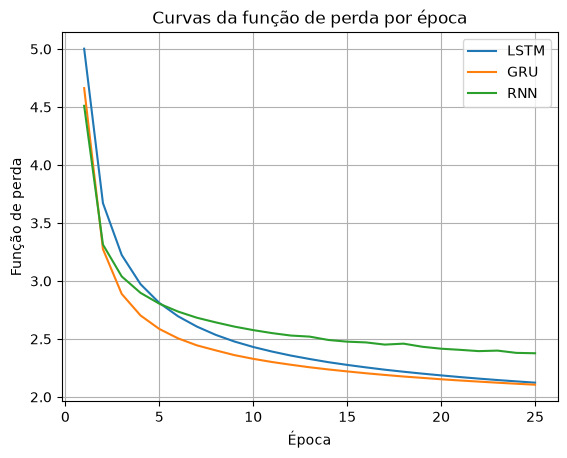

In [19]:
# Compara as curvas de treinamento das três arquiteturas recorrentes.
plt.figure()

for rnn_type in RNN_TYPES:

    losses = resultados_rnn[rnn_type]["losses"]
    epochs = range(1, len(losses) + 1)

    plt.plot(
        epochs,
        losses,
        label=rnn_type.upper()
    )

plt.xlabel("Época")
plt.ylabel("Função de perda")
plt.title("Curvas da função de perda por época")
plt.legend()
plt.grid(True)
plt.show()

### Geração de Textos

#### Classe geradora de textos para um modelo específico ( instância de `RNNModel` )

In [20]:
class TextGenerator:
    """
    Gerador de texto auto-regressivo, a partir de um modelo treinado.

    Esta classe recebe um modelo que, dado um tensor de índices de tokens
    com shape [B, L], devolve logits [B, L, V]. A partir disso, permite
    gerar texto token a token, usando amostragem com temperatura ou modo
    guloso (greedy).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo de linguagem treinado que recebe entradas [B, L] e retorna
        logits [B, L, V].
    itos : list of str
        Lista de mapeamento índice -> token (index-to-string).
    device : str or torch.device, optional
        Dispositivo onde o modelo será executado (por exemplo, "cpu" ou "cuda").
        (default = "cpu")
    """

    def __init__(self, model, itos, device="cpu"):
        self.model = model.to(device)                    # envia o modelo para o dispositivo (CPU ou GPU)
        self.itos = itos                                 # lista índice -> token
        self.stoi = {w: i for i, w in enumerate(itos)}   # dicionário token -> índice (string-to-index)
        self.device = device                             # armazena o dispositivo para uso na geração

    def sample_from(self, probs, temperature=1.0):
        """
        Amostra um índice de token a partir de uma distribuição de probabilidade,
        ajustando-a por uma temperatura.

        Parameters
        ----------
        probs : numpy.ndarray
            Vetor 1D com probabilidades sobre o vocabulário (soma ≈ 1).
        temperature : float, optional
            Fator de "temperatura" para ajustar a distribuição:
            - valores < 1.0 tornam a distribuição mais "aguda" (mais determinística);
            - valores > 1.0 tornam a distribuição mais "achatada" (mais aleatória).
            (default = 1.0)

        Returns
        -------
        idx : int
            Índice de token amostrado da distribuição ajustada.
        p : numpy.ndarray
            Vetor de probabilidades após o ajuste de temperatura e normalização.
        """

        # ajusta a temperatura: eleva as probabilidades à potência 1/temperature
        p = probs ** (1.0 / temperature)
        p = p / p.sum()                                  # renormaliza para que a soma volte a ser 1
        idx = np.random.choice(len(p), p=p)              # amostra um índice de acordo com a distribuição ajustada

        return idx, p

    def generate(self, start_prompt, max_tokens=100, temperature=1.0, greedy=False):
        """
        Gera texto a partir de um prompt inicial, usando o modelo treinado.

        A geração é feita token a token, até atingir max_tokens ou até que
        o token de padding (ID 0) seja gerado.

        Parameters
        ----------
        start_prompt : str
            Texto inicial (prompt) a partir do qual a geração será continuada.
        max_tokens : int, optional
            Número máximo de tokens na sequência gerada (incluindo os do prompt).
            (default = 100)
        temperature : float, optional
            Temperatura usada na amostragem:
            - ignorado se greedy=True;
            - quanto menor, mais determinística a amostragem.
            (default = 1.0)
        greedy : bool, optional
            Se True, utiliza estratégia gulosa (sempre escolhe o token de maior
            probabilidade no passo atual). Se False, utiliza amostragem com temperatura.
            (default = False)

        Returns
        -------
        list of dict
            Lista de dicionários com informações por passo de geração. Cada item contém:
            - "prompt": texto gerado até aquele passo;
            - "word_probs": vetor numpy com a distribuição de probabilidade sobre o vocabulário;
            - "selected_idx": índice do token selecionado naquele passo;
            - "selected_word": token selecionado naquele passo.
        """

        tokens = [self.stoi.get(tok, 1) for tok in start_prompt.lower().split()]    # converte o prompt inicial em índices; tokens fora do vocabulário recebem ID 1 (<UNK>)
        generated = tokens.copy()                                                   # sequência de índices gerada até o momento
        info = []                                                                   # lista para armazenar probabilidades em cada passo
        self.model.eval()                                                           # coloca o modelo em modo de avaliação
        with torch.no_grad():                                                       # desativa gradientes
            while len(generated) < max_tokens and generated[-1] != 0:               # continua gerando enquanto não atingir max_tokens e não for gerado o token <PAD> (ID 0)
                x = torch.tensor([generated], device=self.device)                   # cria tensor de entrada com shape [1, seq_len]
                logits = self.model(x)                                              # obtém logits do modelo: [1, seq_len, V]
                probs = F.softmax(
                    logits[0, -1],                                                  # pega logits do último passo de tempo [V]
                    dim=-1
                ).cpu().numpy()                                                     # converte para probabilidades no CPU como numpy array
                if greedy:
                    idx = int(probs.argmax())                                       # modo guloso: escolhe o índice de maior probabilidade
                    p = probs                                                       # mantém a distribuição original
                else:
                    idx, p = self.sample_from(
                        probs,
                        temperature
                    )                                                               # modo estocástico: amostra usando temperatura

                # Registra o estado da geração, a distribuição utilizada para
                # selecionar o próximo token e o token efetivamente selecionado.
                # As duas últimas informações permitem analisar posteriormente
                # decisões interessantes sem depender da posição fixa do passo.
                info.append({
                    "prompt": " ".join(self.itos[t] for t in generated),
                    "word_probs": p,
                    "selected_idx": idx,
                    "selected_word": self.itos[idx]
                })
                generated.append(idx)                                               # adiciona o novo token gerado à sequência

        text = " ".join(self.itos[i] for i in generated)                            # converte a sequência final de índices de volta para texto
        mode = "GREEDY" if greedy else f"TEMP={temperature}"
        print(f"\nGenerated text ({mode}):\n{text}\n")                              # exibe o texto gerado na saída padrão

        return info                                                                 # retorna informações detalhadas de cada passo

In [21]:
# Configuração comum utilizada na geração de texto para os três modelos.
PROMPT = "recipe for roasted vegetables | "
MAX_GENERATED_TOKENS = 25

# Estratégias de geração que serão comparadas.
# No modo greedy, a temperatura é ignorada pela classe TextGenerator.
GENERATION_CONFIGS = [
    ("Temperatura 1.5", 1.5, False),
    ("Temperatura 1.0", 1.0, False),
    ("Temperatura 0.2", 0.2, False),
    ("Greedy",          1.0, True)
]

#### Loop gerador de textos para cada modelo

In [22]:
# Gera textos com cada uma das arquiteturas recorrentes utilizando
# exatamente o mesmo prompt e as mesmas estratégias de geração.
for rnn_type in RNN_TYPES:

    model = resultados_rnn[rnn_type]["model"]

    # Cria um gerador de texto associado ao modelo atual.
    generator = TextGenerator(
        model=model,
        itos=ds.itos,
        device=DEVICE
    )

    print("\n" + "=" * 70)
    print(f"MODELO: {rnn_type.upper()}")
    print("=" * 70)

    # Armazena os resultados das diferentes estratégias de geração.
    resultados_rnn[rnn_type]["generations"] = {}

    for config_name, temperature, greedy in GENERATION_CONFIGS:

        # Reinicia a semente antes de cada geração para que todos os
        # experimentos estocásticos partam do mesmo estado aleatório.
        np.random.seed(SEED)

        print(f"\n{config_name}")
        print("-" * 70)

        # Gera o texto utilizando a estratégia atual.
        info = generator.generate(
            start_prompt=PROMPT,
            max_tokens=MAX_GENERATED_TOKENS,
            temperature=temperature,
            greedy=greedy
        )

        # Armazena as informações da geração para análise posterior.
        resultados_rnn[rnn_type]["generations"][config_name] = info

        # Exibe somente as três palavras com maior probabilidade no
        # primeiro passo após o prompt.
        print_probs_pt(
            info[:1],
            ds.itos,
            top_k=3
        )


MODELO: LSTM

Temperatura 1.5
----------------------------------------------------------------------

Generated text (TEMP=1.5):
recipe for roasted vegetables | preheat black seed ( cut into 1 day or grinder . snip sections on side of grill small hot )


PROMPT: recipe for roasted vegetables |
preheat          26.26%
in                6.68%
1                 4.13%
--------


Temperatura 1.0
----------------------------------------------------------------------

Generated text (TEMP=1.0):
recipe for roasted vegetables | preheat broiler . lightly oil 2 - quart shallow baking pan or gratin dish . ( can be prepared 1


PROMPT: recipe for roasted vegetables |
preheat          62.72%
in                8.04%
1                 3.91%
--------


Temperatura 0.2
----------------------------------------------------------------------

Generated text (TEMP=0.2):
recipe for roasted vegetables | preheat oven to 350°f . butter and flour two 9 - inch - diameter cake pans with 2 - inch


PROMPT: recipe 

#### Função auxiliar para buscar casos extremos na geração

In [51]:
def find_interesting_cases(generations):
    """
    Procura automaticamente casos interessantes nas gerações de texto.

    Para cada modelo são selecionados dois tipos de caso:

    1. Sampling diferente do argmax:
       procura, entre as gerações estocásticas, o passo em que o token
       selecionado apresenta a maior diferença de probabilidade em relação
       ao token mais provável da distribuição.

    2. Distribuição concentrada:
       procura, entre as gerações com temperatura 0.2, o passo em que
       um único token apresenta a maior probabilidade.

    Parameters
    ----------
    generations : dict
        Dicionário contendo os resultados das estratégias de geração
        armazenados por TextGenerator.generate().

    Returns
    -------
    list of dict
        Casos selecionados automaticamente para análise.
    """

    divergent_cases = []
    concentrated_cases = []

    # Percorre todas as estratégias de geração disponíveis para o modelo.
    for config_name, info in generations.items():

        # O modo greedy não participa da busca por decisões divergentes,
        # pois nele o token selecionado é sempre o próprio argmax.
        is_greedy = config_name == "Greedy"

        # Percorre todos os passos registrados durante a geração.
        for step, step_info in enumerate(info):

            word_probs = np.asarray(step_info["word_probs"])

            # Recupera diretamente o token selecionado durante a geração.
            # Essas informações são armazenadas pela própria TextGenerator.
            selected_idx = step_info["selected_idx"]
            selected_word = step_info["selected_word"]
            selected_prob = float(word_probs[selected_idx])

            # Identifica o token com maior probabilidade no passo atual.
            argmax_idx = int(np.argmax(word_probs))
            argmax_word = ds.itos[argmax_idx]
            argmax_prob = float(word_probs[argmax_idx])

            # Nas estratégias estocásticas, procura situações em que o
            # token efetivamente amostrado não corresponde ao argmax.
            if not is_greedy and selected_idx != argmax_idx:

                # Quanto maior esta diferença, mais evidente é o efeito
                # da amostragem sobre a decisão produzida pelo modelo.
                probability_gap = argmax_prob - selected_prob

                divergent_cases.append({
                    "type": "divergent",
                    "config_name": config_name,
                    "step": step,
                    "selected_word": selected_word,
                    "selected_prob": selected_prob,
                    "argmax_word": argmax_word,
                    "argmax_prob": argmax_prob,
                    "score": probability_gap
                })

            # Para ilustrar o efeito de baixa temperatura, considera apenas
            # a geração com temperatura 0.2 e procura a distribuição mais
            # concentrada encontrada durante a sequência.
            if config_name == "Temperatura 0.2":

                concentrated_cases.append({
                    "type": "concentrated",
                    "config_name": config_name,
                    "step": step,
                    "selected_word": selected_word,
                    "selected_prob": selected_prob,
                    "argmax_word": argmax_word,
                    "argmax_prob": argmax_prob,
                    "score": argmax_prob
                })

    # Seleciona o caso em que a amostragem mais se afastou do token
    # que possuía a maior probabilidade.
    divergent_case = (
        max(divergent_cases, key=lambda case: case["score"])
        if divergent_cases
        else None
    )

    # Seleciona o caso de temperatura baixa em que a distribuição
    # apresentou a maior concentração em um único token.
    concentrated_case = (
        max(concentrated_cases, key=lambda case: case["score"])
        if concentrated_cases
        else None
    )

    # Remove eventuais casos inexistentes e devolve somente os exemplos
    # efetivamente encontrados nesta execução.
    return [
        case
        for case in [divergent_case, concentrated_case]
        if case is not None
    ]

#### Identifica e mostra casos extremos na geração de textos

In [52]:

# Procura automaticamente casos interessantes para cada uma das
# arquiteturas recorrentes, evitando depender de passos fixos que
# poderiam mudar após um novo treinamento.
for rnn_type in RNN_TYPES:

    generations = resultados_rnn[rnn_type]["generations"]

    interesting_cases = find_interesting_cases(
        generations
    )

    # Exibe os casos encontrados utilizando a mesma apresentação de
    # probabilidades empregada nas demais análises do notebook.
    for case in interesting_cases:

        print("\n" + "=" * 70)

        if case["type"] == "divergent":
            description = "Sampling diferente do argmax"
        else:
            description = "Distribuição concentrada"

        print(
            f"{rnn_type.upper()} | "
            f"{case['config_name']} | "
            f"Passo {case['step'] + 1} | "
            f"{description}"
        )

        print("=" * 70)

        # Recupera o passo completo armazenado durante a geração.
        info = generations[case["config_name"]]

        # Exibe as três palavras mais prováveis naquele passo.
        print_probs_pt(
            info[case["step"]:case["step"] + 1],
            ds.itos,
            top_k=3
        )

        # Exibe explicitamente qual token foi efetivamente selecionado,
        # permitindo compará-lo com a previsão de maior probabilidade.
        print(
            f"Token selecionado: {case['selected_word']} "
            f"({case['selected_prob'] * 100:.2f}%)"
        )

        print(
            f"Token mais provável: {case['argmax_word']} "
            f"({case['argmax_prob'] * 100:.2f}%)"
        )


LSTM | Temperatura 1.0 | Passo 2 | Sampling diferente do argmax

PROMPT: recipe for roasted vegetables | preheat
oven             87.26%
broiler           9.70%
the               2.08%
--------

Token selecionado: broiler (9.70%)
Token mais provável: oven (87.26%)

LSTM | Temperatura 0.2 | Passo 3 | Distribuição concentrada

PROMPT: recipe for roasted vegetables | preheat oven
to              100.00%
and               0.00%
.                 0.00%
--------

Token selecionado: to (100.00%)
Token mais provável: to (100.00%)

GRU | Temperatura 1.0 | Passo 11 | Sampling diferente do argmax

PROMPT: recipe for roasted vegetables | whisk buttermilk , wine , and 1 teaspoon lemon juice
in               91.44%
,                 2.10%
and               2.02%
--------

Token selecionado: , (2.10%)
Token mais provável: in (91.44%)

GRU | Temperatura 0.2 | Passo 3 | Distribuição concentrada

PROMPT: recipe for roasted vegetables | preheat oven
to              100.00%
and               0.00%
up    

## **Seção 6 — MiniGPT**

### Hiperparâmetros específicos para o MiniGPT

Nesta seção está a resolução do laboratorio 6 referente aos modelos auto-regressivos com transformadores. Segundo especificação, ele mantém os mesmos hiperparametros do laboratorio da [Seção 5 — Modelos auto-regressivos com RNNs](#seção-5--modelos-auto-regressivos-com-rnns), abaixo reproduzidos apenas para simplificar a referência. 

| Parâmetro | Valor | Descrição |
|---|--:|---|
| `VOCAB_SIZE` | 10_000 | Número máximo de tokens no vocabulário |
| `MAX_LEN` | 200 | Comprimento máximo da sequência de entrada |
| `EMBEDDING_DIM` | 100 | Dimensão dos vetores de palavras |
| `BATCH_SIZE` | 32 | Número de exemplos por lote |
| `EPOCHS` | 25 | Número de passadas pelo conjunto de treinamento |
| `LEARNING_RATE` | 1e-3 | Passo usado pelo otimizador |
| `SEED`| 42 | Semente geradora de numeros aleatórios fixa para reprodutibilidade |

In [ ]:
# Hiperparâmetros específicos do MiniGPT, conforme a configuração
# base do Laboratório 6.
N_HEADS          = 2       # número de cabeças de atenção no caso base
FEED_FORWARD_DIM = 256     # dimensão do MLP interno do bloco Transformador no caso base

# O Lab 6 reutiliza diretamente o vocabulário construído no Lab 5.
vocab = ds.itos

### Redes Neurais

#### Camada de Transformação de Embeddings semanticos e posicionais

In [25]:
class TokenAndPositionEmbedding(nn.Module):
    """
    Camada que combina embedding de tokens e embedding posicional por soma.

    A soma exige que os embeddings de token e posição tenham a mesma dimensão.

    Parameters
    ----------
    max_len : int
        Comprimento máximo das sequências / número máximo de posições representáveis.
    vocab_size : int
        Tamanho do vocabulário (número máximo de tokens distintos).
    embed_dim : int
        Dimensão dos vetores de embedding para tokens e posições.

    Attributes
    ----------
    max_len : int
        Armazena o comprimento máximo da sequência.
    vocab_size : int
        Armazena o tamanho do vocabulário.
    embed_dim : int
        Armazena a dimensão do embedding.
    token_emb : nn.Embedding
        Embedding de tokens: índices de tokens -> vetores de dimensão embed_dim.
    pos_emb : nn.Embedding
        Embedding posicional: índices de posição -> vetores de dimensão embed_dim.
    """

    def __init__(self, max_len: int, vocab_size: int, embed_dim: int) -> None:

        super().__init__()            # inicializa a base nn.Module
        self.max_len = max_len        # comprimento máximo da sequência
        self.vocab_size = vocab_size  # tamanho do vocabulário
        self.embed_dim = embed_dim    # dimensão dos embeddings (token e posição)

        # Camada de embedding de tokens (treinável)
        self.token_emb = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim
        )

        # Camada de embedding posicional (treinável)
        self.pos_emb = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=embed_dim
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagação direta.
        Soma embeddings de token e posição.

        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada contendo índices de tokens com shape (B, S),
            onde B = tamanho do lote e S = comprimento da sequência.

        Returns
        -------
        torch.Tensor
            Embeddings combinados com shape (B, S, D),
            onde D = dimensão dos embeddings.
        """

        B, S = x.shape                                          # x: (B, S) -> extrai o tamanho do lote (B) e comprimento da sequência (S)

        positions = (                                           # constrói índices de posição para cada elemento do lote
            torch.arange(S, device=x.device)                    # cria [0, 1, ..., S-1] -> shape (S,)
            .unsqueeze(0)                                       # adiciona dimensão de lote -> shape (1, S)
            .expand(B, S)                                       # replica para cada item do lote -> shape (B, S)
        )

        token_embeddings = self.token_emb(x)                    # aplica embedding de tokens: (B, S) -> (B, S, D)
        pos_embeddings = self.pos_emb(positions)                # aplica embedding posicional: (B, S) -> (B, S, D)

        return token_embeddings + pos_embeddings                # combina informação semântica + ordem temporal por soma

    def extra_repr(self) -> str:
        return (                                                # define string extra para print/summary do módulo
            f"max_len={self.max_len}, "
            f"vocab_size={self.vocab_size}, "
            f"embed_dim={self.embed_dim}"
        )

#### Camada de Transformação e Máscara Causal

In [26]:
class MaskedTransformerLayer(nn.Module):
    """
    Bloco Transformer (do tipo decoder-only) com máscara causal.

    Este bloco implementa:
    1) Autoatenção com máscara causal (impede acesso a tokens futuros).
    2) Conexão residual + normalização por camada.
    3) MLP posição-a-posição (feed-forward) + conexão residual + normalização por camada.

    Parameters
    ----------
    embed_dim : int
        Dimensão dos vetores de embedding e atenção.
    num_heads : int
        Número de cabeças de atenção múltipla.
    ff_dim : int
        Dimensão da camada intermediária no MLP.
    dropout : float, optional
        Taxa de dropout aplicada à camada de atenção e ao MLP. Default: 0.1.

    Attributes
    ----------
    attn : nn.MultiheadAttention
        Camada de autoatenção múltipla que opera sobre (batch_size, seq_len, embed_dim).
    layer_norm_1 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de atenção.
    mlp : nn.Sequential
        Rede MLP interna (Linear → ReLU → Linear → Dropout).
    layer_norm_2 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de MLP.

    Notes
    -----
    A máscara causal impede que cada token no passo t "veja" tokens em posições > t.
    """

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        ff_dim: int,
        dropout: float = 0.1
    ) -> None:

        super().__init__()                                                      # inicializa a base nn.Module

        # self.attn: Autoatenção de múltiplas cabeças usando x como Q, K e V
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,                                                # dimensão dos vetores de entrada/saída da atenção
            num_heads=num_heads,                                                # número de cabeças de atenção
            dropout=dropout,                                                    # dropout aplicado internamente pela atenção
            batch_first=True                                                    # formato esperado: (B, S, D)
        )

        # self.layer_norm_1: normalização aplicada após a conexão residual da atenção
        self.layer_norm_1 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 1

        # self.mlp: rede feed-forward aplicada a cada token (Linear → ReLU → Linear → Dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),                                       # projeta D -> ff_dim
            nn.ReLU(),                                                          # não-linearidade do MLP
            nn.Linear(ff_dim, embed_dim),                                       # projeta ff_dim -> D
            nn.Dropout(dropout)                                                 # dropout na saída do MLP (regularização)
        )

        # self.layer_norm_2: normalização aplicada após a conexão residual do MLP
        self.layer_norm_2 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 2

    @staticmethod
    def _causal_mask(
        sz: int,
        device: torch.device | None = None
    ) -> torch.Tensor:
        """
        Cria máscara causal booleana com shape (sz, sz).

        Parameters
        ----------
        sz : int
            Comprimento da sequência (S).
        device : torch.device | None, optional
            Dispositivo onde a máscara será criada.

        Returns
        -------
        torch.Tensor
            Máscara booleana triangular superior:
            True  -> posições mascaradas (futuras),
            False -> posições permitidas.
        """

        return torch.triu(
            torch.ones(sz, sz, dtype=torch.bool, device=device),  # matriz cheia de True/1
            diagonal=1                                            # zera diagonal principal e parte inferior
        )

    def forward(
        self,
        x: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Propagação direta do bloco Transformador (mascarado).

        Parameters
        ----------
        x : torch.Tensor
            Entrada com shape (B, S, D), onde:
            B = tamanho do lote, S = comprimento da sequência, D = dimensão dos embeddings.

        Returns
        -------
        x_out : torch.Tensor
            Saída do bloco com shape (B, S, D).
        attn_output_weights : torch.Tensor
            Pesos de atenção. Pode ter forma (B, H, S, S) ou (B, S, S),
            dependendo da configuração de heads.
        """

        seq_len = x.shape[1]                                                    # x tem shape (B, S, D) -> extrai o comprimento da sequência (S)

        attn_mask = self._causal_mask(
            seq_len,
            x.device
        )                                                                       # máscara causal com shape (S, S)

        attn_output, attn_output_weights = self.attn(                           # Aplica a camada de autoatenção causal de múltiplas cabeças
            x,                                                                  # Query = x
            x,                                                                  # Key   = x
            x,                                                                  # Value = x
            attn_mask=attn_mask,                                                # impede atenção a tokens futuros
            need_weights=True,                                                  # retorna pesos de atenção
            average_attn_weights=True                                           # retorna média dos pesos entre cabeças
        )

        # Bloco "Add & Norm" (#1):
        #   1. Conexão residual: x (entrada original) + attn_output (saída da atenção).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        z = self.layer_norm_1(x + attn_output)                                  # Add & Norm #1: residual da atenção

        mlp_output = self.mlp(z)                                                # Aplica a rede MLP sobre z: (B, S, D) -> (B, S, D)

        # Bloco "Add & Norm" (#2):
        #   1. Conexão residual: z (entrada ao bloco MLP) + mlp_output (saída da rede MLP).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        x_out = self.layer_norm_2(z + mlp_output)                               # Add & Norm #2: residual do MLP

        return x_out, attn_output_weights                                       # retorna (saída do bloco, pesos de atenção)

#### Camada Linear e LogSoftmax

In [27]:
class LSM(nn.Module):
    """
    Aplica Linear seguido de LogSoftmax.

    Parameters
    ----------
    embed_dim : int
        Dimensão de entrada (tamanho do embedding vindo do Transformer).
    vocab_size : int
        Número de classes (tamanho do vocabulário).
    bias : bool, optional
        Se a camada Linear deve ter viés (bias). Default: False.
    """

    def __init__(
        self,
        embed_dim: int,
        vocab_size: int,
        bias: bool = False
    ) -> None:

        super().__init__()

        # Projeta de embed_dim para vocab_size (logits)
        self.linear = nn.Linear(
            in_features=embed_dim,
            out_features=vocab_size,
            bias=bias
        )

        # Converte logits em log-probabilidades
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada com shape (..., embed_dim).

        Returns
        -------
        torch.Tensor
            Log-probabilidades com shape (..., vocab_size).
        """

        logits = self.linear(x)

        return self.log_softmax(logits)

#### Composição das camadas num GPTMini

In [28]:
class GPTMini(nn.Module):
    """
    Modelo GPT simplificado (decoder-only) para geração de texto.

    Parameters
    ----------
    vocab_size : int
        Tamanho do vocabulário (número de tokens únicos).
    max_len : int
        Comprimento máximo das sequências (número de posições para embeddings posicionais).
    embed_dim : int
        Dimensão dos vetores de embedding (tanto para token quanto para posição).
    num_heads : int
        Número de cabeças de atenção múltipla no bloco Transformer.
    ff_dim : int
        Dimensão da camada intermediária no MLP do bloco Transformer.

    Attributes
    ----------
    embed_layer : TokenAndPositionEmbedding
        Camada que soma embeddings de token e posicionais.
    block : MaskedTransformerLayer
        Bloco Transformer (decoder-only) aplicado sobre a soma token_emb + pos_emb.
    lsm : LSM
        Camada linear + LogSoftmax que projeta vetores de dimensão embed_dim
        de volta ao espaço de vocabulário (tamanho vocab_size).
    """

    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        embed_dim: int,
        num_heads: int,
        ff_dim: int
    ) -> None:

        super().__init__()

        # Camada de embeddings (tokens + posição)
        self.embed_layer = TokenAndPositionEmbedding(
            max_len=max_len,
            vocab_size=vocab_size,
            embed_dim=embed_dim
        )

        # Bloco Transformer (atenção causal + MLP)
        self.block = MaskedTransformerLayer(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim
        )

        # Camada final LSM: Linear + LogSoftmax
        self.lsm = LSM(
            embed_dim=embed_dim,
            vocab_size=vocab_size,
            bias=True
        )

    def forward(
        self,
        toks: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Executa a propagação direta do GPTMini.

        Parameters
        ----------
        toks : torch.Tensor
            Tensor de entrada contendo índices de tokens, com forma (B, S).
            Cada valor deve estar no intervalo [0, vocab_size).

        Returns
        -------
        log_probs : torch.Tensor
            Log-probabilidades para cada token no vocabulário,
            com shape (B, S, V).
        attn_weights : torch.Tensor
            Pesos de atenção do bloco Transformer.
        """

        # Gera o tensor resultante da soma de token + pos embeddings
        x: torch.Tensor = self.embed_layer(toks)                                # (B, S, D)

        # Passa pela cabeça do Transformer (atenção causal + MLP)
        h, attn = self.block(x)                                                 # (B, S, D), pesos de atenção

        # Projeta saída h do Transformer para log-probabilidades sobre o vocabulário
        log_probs = self.lsm(h)                                                # (B, S, V)

        # Retorna as log-probabilidades e os pesos de atenção
        return log_probs, attn

### Treinamento dos modelos

#### Calculo do negativo do logaritmo da verossimilhança (negative log-likelihood - NLL)

In [29]:
def compute_nll_logprobs(log_probs, targets, loss_fn):
    """
    Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL)
    agregada sobre todos os tokens do batch, reformatando log-probabilidades e alvos
    para o shape esperado por NLLLoss.

    Parameters
    ----------
    log_probs : torch.Tensor
        Tensor de log-probabilidades com shape [B, S, V], onde:
        B = batch_size, S = comprimento da sequência, V = tamanho do vocabulário.
        Tipicamente é a saída direta de um modelo que aplica LogSoftmax na última dimensão.
    targets : torch.Tensor
        Tensor de alvos com shape [B, S], contendo IDs de tokens.
    loss_fn : torch.nn.Module
        Instância de função de perda compatível com log-probabilidades
        (ex.: nn.NLLLoss).

    Returns
    -------
    torch.Tensor
        Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
    """

    B, S, V = log_probs.shape       # B: tamanho do lote, S: comprimento da sequência, V: tamanho do vocabulário

    loss = loss_fn(
        log_probs.view(B * S, V),   # reshape de [B, S, V] -> [N, C], onde:
                                    #   N = B*S (um "exemplo" por token do lote)
                                    #   C = V   (número de classes = tamanho do vocabulário)
                                    # NLLLoss espera log-probabilidades nesse formato [N, C].
        targets.view(B * S)         # reshape de [B, S] -> [N], com:
                                    #   N = B*S (um rótulo inteiro por token do lote)
                                    # NLLLoss espera alvos 1D [N] alinhados com as linhas das predições.
    )

    return loss

#### Função de treinamento completo de um modelo específico ( instância de `MiniGPT` )

In [30]:
def train_minigpt(
    model,
    dataloader,
    optimizer,
    criterion,
    device: str = DEVICE,
    epochs: int = EPOCHS
) -> list[float]:
    """
    Treina o modelo pelo número de épocas especificado e retorna
    uma lista com a loss média por lote em cada época.

    Parameters
    ----------
    model : nn.Module
        Modelo PyTorch a ser treinado.
    dataloader : DataLoader
        DataLoader que fornece batches de (x, y).
    optimizer : torch.optim.Optimizer
        Otimizador para atualizar os pesos do modelo.
    criterion : callable
        Função de perda compatível com log-probabilidades
        (ex.: nn.NLLLoss com ignore_index=0).
    device : torch.device
        Dispositivo onde o modelo e dados serão alocados.
    epochs : int
        Número de épocas de treinamento.

    Returns
    -------
    losses_per_epoch : list of float
        Lista de tamanho `epochs`, onde cada elemento é a loss média
        por batch naquela época.
    """

    losses_per_epoch = []                                              # lista que armazenará a loss média de cada época

    # Loop principal de treinamento, iterando de 1 até epochs
    for epoch in tqdm(range(1, epochs + 1), desc="Épocas", unit="época"):

        model.train()                                                   # coloca o modelo em modo de treinamento (ativa dropout, etc.)
        running_loss = 0.0                                              # acumulador da loss ao longo dos batches desta época

        # Loop sobre todos os batches do dataloader
        for x, y in tqdm(dataloader, desc="Lotes", leave=False):

            x = x.to(device)                                            # move o batch de entrada para o dispositivo; x: [B, S]
            y = y.to(device)                                            # move o batch de alvos para o dispositivo;   y: [B, S]

            optimizer.zero_grad()                                       # zera gradientes acumulados de iterações anteriores

            log_probs, _ = model(x)                                     # forward do modelo; log_probs: [B, S, V]

            loss = compute_nll_logprobs(                                # calcula NLL agregada no batch
                log_probs,
                y,
                criterion
            )

            loss.backward()                                             # retropropagação: calcula gradientes
            optimizer.step()                                            # atualiza os parâmetros do modelo

            running_loss += loss.item()                                 # acumula o valor escalar da loss deste batch

        avg_loss = running_loss / len(dataloader)                       # calcula a loss média da época
        losses_per_epoch.append(avg_loss)                               # armazena a loss média desta época

    return losses_per_epoch                                             # devolve a lista de losses médias por época

#### Cáculo da perplexidade de um modelo específico ( instância de `MiniGPT` )

In [31]:
def compute_minigpt_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um MiniGPT em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        MiniGPT já treinado que recebe tensores [B, S] e retorna
        log-probabilidades [B, S, V] e pesos de atenção.
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.NLLLoss(
        ignore_index=0,                                        # ignora o token <PAD> (ID 0)
        reduction="sum"                                        # soma a NLL sobre os tokens válidos
    )

    with torch.no_grad():                                      # bloco sem cálculo de gradiente
        for x_batch, y_batch in data_loader:

            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            log_probs, _ = model(x_batch)                      # obtém log-probabilidades: [B, S, V]

            loss = compute_nll_logprobs(
                log_probs,
                y_batch,
                loss_fn
            )

            total_loss += loss                                 # acumula a soma das perdas
            total_tokens += (y_batch != 0).sum()               # conta tokens não-PAD

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média)

    return avg_nll.item(), ppl.item()

#### Setup dos experimentos

In [32]:
# Configurações dos experimentos do MiniGPT.
#
# Em cada experimento, apenas um hiperparâmetro é alterado em relação
# à configuração base. A dimensão do embedding deve ser divisível
# pelo número de cabeças de atenção.

MINIGPT_EXPERIMENTS = {
    "base": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": N_HEADS,
        "ff_dim": FEED_FORWARD_DIM
    },

    "embedding-64": {
        "embed_dim": 64,
        "num_heads": N_HEADS,
        "ff_dim": FEED_FORWARD_DIM
    },

    "embedding-128": {
        "embed_dim": 128,
        "num_heads": N_HEADS,
        "ff_dim": FEED_FORWARD_DIM
    },

    "heads-1": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": 1,
        "ff_dim": FEED_FORWARD_DIM
    },

    "heads-4": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": 4,
        "ff_dim": FEED_FORWARD_DIM
    },

    "ff-128": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": N_HEADS,
        "ff_dim": 128
    },

    "ff-512": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": N_HEADS,
        "ff_dim": 512
    }
}

# Valida a restrição exigida pelo MultiheadAttention:
# EMBEDDING_DIM precisa ser divisível por N_HEADS.
for experiment_name, config in MINIGPT_EXPERIMENTS.items():

    assert config["embed_dim"] % config["num_heads"] == 0, (
        f"Configuração inválida em '{experiment_name}': "
        f"embed_dim={config['embed_dim']} não é divisível por "
        f"num_heads={config['num_heads']}."
    )

#### Geração de path de salvamento do checkpoint conforme cada modelo

In [33]:
def get_minigpt_checkpoint_path(experiment_name):
    """
    Retorna o caminho do checkpoint correspondente a um experimento MiniGPT.

    Parameters
    ----------
    experiment_name : str
        Nome identificador do experimento.

    Returns
    -------
    pathlib.Path
        Caminho do arquivo de checkpoint.
    """

    return CHECKPOINT_DIR / f"lab6-minigpt-{experiment_name}.pt"

#### Salvamento de um checkpoint

In [34]:
def save_minigpt_checkpoint(
    experiment_name,
    model,
    config,
    losses,
    test_nll,
    test_ppl,
    num_params
):
    """
    Salva o estado do MiniGPT e os resultados associados ao experimento.
    """

    checkpoint_path = get_minigpt_checkpoint_path(experiment_name)

    checkpoint = {
        "experiment_name": experiment_name,
        "config": config,
        "model_state_dict": model.state_dict(),
        "losses": losses,
        "test_nll": test_nll,
        "test_ppl": test_ppl,
        "num_params": num_params
    }

    torch.save(checkpoint, checkpoint_path)

    print(f"Checkpoint salvo em: {checkpoint_path}")

#### Recuperação de um checkpoint

In [35]:
def load_minigpt_checkpoint(experiment_name):
    """
    Carrega o checkpoint de um experimento MiniGPT e reconstrói o modelo.

    Parameters
    ----------
    experiment_name : str
        Nome identificador do experimento.

    Returns
    -------
    dict
        Dicionário contendo o modelo reconstruído e os resultados
        previamente armazenados.
    """

    checkpoint_path = get_minigpt_checkpoint_path(experiment_name)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    config = checkpoint["config"]

    model = GPTMini(
        vocab_size=len(vocab),
        max_len=MAX_LEN,
        embed_dim=config["embed_dim"],
        num_heads=config["num_heads"],
        ff_dim=config["ff_dim"]
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])

    return {
        "model": model,
        "config": config,
        "losses": checkpoint["losses"],
        "test_nll": checkpoint["test_nll"],
        "test_ppl": checkpoint["test_ppl"],
        "num_params": checkpoint["num_params"]
    }

#### Execução dos treinamentos

In [36]:
# Dicionário que concentra os modelos e resultados produzidos
# pelos experimentos com o MiniGPT.
resultados_minigpt = {}

# Função de perda utilizada em todos os experimentos.
# O MiniGPT retorna log-probabilidades, portanto usamos NLLLoss.
criterion_minigpt = nn.NLLLoss(ignore_index=0)

for experiment_name, config in MINIGPT_EXPERIMENTS.items():

    checkpoint_path = get_minigpt_checkpoint_path(experiment_name)

    print(f"\n{'=' * 70}")
    print(f"Experimento MiniGPT: {experiment_name}")
    print(
        f"embed_dim={config['embed_dim']}, "
        f"num_heads={config['num_heads']}, "
        f"ff_dim={config['ff_dim']}"
    )
    print(f"{'=' * 70}")

    if checkpoint_path.exists():

        print("Checkpoint encontrado. Carregando experimento...")

        resultados_minigpt[experiment_name] = (
            load_minigpt_checkpoint(experiment_name)
        )

    else:

        # O enunciado exige que cada experimento seja iniciado com a
        # mesma semente e com uma nova instância do modelo.
        torch.manual_seed(SEED)

        model = GPTMini(
            vocab_size=len(vocab),
            max_len=MAX_LEN,
            embed_dim=config["embed_dim"],
            num_heads=config["num_heads"],
            ff_dim=config["ff_dim"]
        ).to(DEVICE)

        # Um novo otimizador é criado imediatamente após o novo modelo,
        # conforme exigido pelo enunciado do laboratório.
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE
        )

        losses = train_minigpt(
            model=model,
            dataloader=train_dl,
            optimizer=optimizer,
            criterion=criterion_minigpt,
            device=DEVICE,
            epochs=EPOCHS
        )

        test_nll, test_ppl = compute_minigpt_perplexity(
            model,
            test_dl
        )

        num_params = sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        )

        resultados_minigpt[experiment_name] = {
            "model": model,
            "config": config,
            "losses": losses,
            "test_nll": test_nll,
            "test_ppl": test_ppl,
            "num_params": num_params
        }

        # O checkpoint é salvo imediatamente após o término do
        # experimento para evitar a perda do treinamento realizado.
        save_minigpt_checkpoint(
            experiment_name=experiment_name,
            model=model,
            config=config,
            losses=losses,
            test_nll=test_nll,
            test_ppl=test_ppl,
            num_params=num_params
        )

    result = resultados_minigpt[experiment_name]

    print(
        f"NLL: {result['test_nll']:.4f} | "
        f"PPL: {result['test_ppl']:.2f} | "
        f"Parâmetros: {result['num_params']:,}"
    )


Experimento MiniGPT: base
embed_dim=100, num_heads=2, ff_dim=256


Épocas: 100%|██████████| 25/25 [07:21<00:00, 17.64s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-base.pt
NLL: 2.3841 | PPL: 10.85 | Parâmetros: 2,122,356

Experimento MiniGPT: embedding-64
embed_dim=64, num_heads=2, ff_dim=256


Épocas: 100%|██████████| 25/25 [05:35<00:00, 13.42s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-embedding-64.pt
NLL: 2.5663 | PPL: 13.02 | Parâmetros: 1,352,784

Experimento MiniGPT: embedding-128
embed_dim=128, num_heads=2, ff_dim=256


...

Checkpoint salvo em: checkpoints/lab6-minigpt-heads-4.pt
NLL: 2.3670 | PPL: 10.67 | Parâmetros: 2,122,356

Experimento MiniGPT: ff-128
embed_dim=100, num_heads=2, ff_dim=128


Épocas: 100%|██████████| 25/25 [07:14<00:00, 17.40s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-ff-128.pt
NLL: 2.4198 | PPL: 11.24 | Parâmetros: 2,096,628

Experimento MiniGPT: ff-512
embed_dim=100, num_heads=2, ff_dim=512


Épocas: 100%|██████████| 25/25 [07:26<00:00, 17.85s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-ff-512.pt
NLL: 2.3446 | PPL: 10.43 | Parâmetros: 2,173,812


### Comparação das curvas de perda de treinamento dos modelos

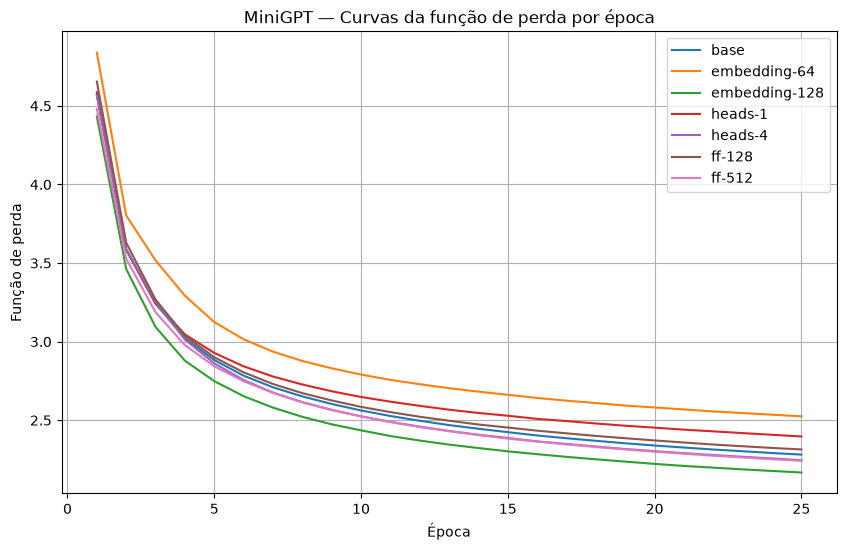

In [37]:
# Compara as curvas de perda dos diferentes experimentos MiniGPT.

plt.figure(figsize=(10, 6))

for experiment_name, result in resultados_minigpt.items():

    epochs = range(1, len(result["losses"]) + 1)

    plt.plot(
        epochs,
        result["losses"],
        label=experiment_name
    )

plt.xlabel("Época")
plt.ylabel("Função de perda")
plt.title("MiniGPT — Curvas da função de perda por época")
plt.legend()
plt.grid(True)
plt.show()

### Tabela comparativa entre os experimentos

In [38]:
# Exibe os resultados obtidos em todos os experimentos MiniGPT.

print(
    f"{'Experimento':<20} "
    f"{'Embedding':>10} "
    f"{'Heads':>7} "
    f"{'FF':>7} "
    f"{'NLL':>10} "
    f"{'PPL':>10} "
    f"{'Parâmetros':>15}"
)

print("-" * 86)

for experiment_name, result in resultados_minigpt.items():

    config = result["config"]

    print(
        f"{experiment_name:<20} "
        f"{config['embed_dim']:>10} "
        f"{config['num_heads']:>7} "
        f"{config['ff_dim']:>7} "
        f"{result['test_nll']:>10.4f} "
        f"{result['test_ppl']:>10.2f} "
        f"{result['num_params']:>15,}"
    )

Experimento           Embedding   Heads      FF        NLL        PPL      Parâmetros
--------------------------------------------------------------------------------------
base                        100       2     256     2.3841      10.85       2,122,356
embedding-64                 64       2     256     2.5663      13.02       1,352,784
embedding-128               128       2     256     2.3146      10.12       2,728,080
heads-1                     100       1     256     2.4761      11.90       2,122,356
heads-4                     100       4     256     2.3670      10.67       2,122,356
ff-128                      100       2     128     2.4198      11.24       2,096,628
ff-512                      100       2     512     2.3446      10.43       2,173,812


### Geração de Textos


#### Classe geradora de textos para um modelo específico ( instância de `MiniGPT` )

In [46]:
# CLASSE TextGeneratorMiniGPT – gera texto passo a passo com o modelo treinado
class TextGeneratorMiniGPT:
    """
    Gera texto autoregressivamente com base num modelo MiniGPT treinado.

    Attributes
    ----------
    idx_to_word : list[str]
        Lista de mapeamento índice → palavra.
    word_to_idx : dict[str, int]
        Dicionário de mapeamento palavra → índice.
    default_temperature : float
        Temperatura padrão de amostragem.
    """

    def __init__(self, idx_to_word: list[str], temperature: float = 1.0):

        self.idx_to_word = idx_to_word                                  # mapeamento índice → palavra
        self.word_to_idx = {w: i for i, w in enumerate(idx_to_word)}    # dicionário inverso palavra → índice
        self.default_temperature = temperature                          # temperatura padrão de amostragem

    def _tokenize(self, txt: str) -> list[str]:
        """
        Converte texto cru em uma lista de tokens utilizando exatamente
        a mesma normalização definida no EpicuriousRecipesDataset do Lab 5.

        A normalização:
        - converte o texto para letras minúsculas;
        - adiciona espaços ao redor dos sinais de pontuação;
        - reduz múltiplos espaços a um único espaço;
        - divide o texto normalizado em tokens.

        Parameters
        ----------
        txt : str
            Texto que será normalizado e tokenizado.

        Returns
        -------
        list[str]
            Lista de tokens produzida a partir do texto normalizado.
        """

        normalized_text = EpicuriousRecipesDataset._pad_punct(txt)

        return normalized_text.split()

    def _sample(self, probs: torch.Tensor, temperature: float) -> int:
        """
        Sorteia 1 token a partir de uma distribuição de probabilidade com temperatura.
        """

        probs = probs ** (1 / temperature)               # aplica temperatura
        probs = probs / probs.sum()                      # re-normaliza para somar 1

        return torch.multinomial(probs, 1).item()        # amostra 1 índice segundo a distribuição ajustada

    @torch.no_grad()                                     # desliga gradiente (inferência)
    def generate(
        self,
        model,
        prompt: str,
        max_tokens: int = MAX_LEN,
        temperature: float | None = None
    ) -> tuple[str, list[dict]]:
        """
        Gera texto passo a passo e coleta estatísticas de atenção e distribuição.

        Returns
        -------
        tuple[str, list[dict]]
            Texto completo gerado e informações coletadas em cada passo.
        """

        model.eval()                                     # ativa modo de avaliação

        temp = (
            self.default_temperature
            if temperature is None
            else temperature
        )

        ids = [
            self.word_to_idx.get(t, 1)
            for t in self._tokenize(prompt)
        ]                                                # prompt → lista de índices (1=<UNK>)

        info: list[dict] = []                            # lista onde cada item = stats de um passo

        while len(ids) < max_tokens and ids[-1] != 0:

            x = torch.tensor([ids], device=DEVICE)       # cria batch (1, S) e move p/ DEVICE

            log_probs, attn = model(x)                   # forward: log_probs (1, S, V) e atenção

            # Extrai os pesos de atenção da última posição.
            if attn.ndim == 4:

                step_atts = (
                    attn[0, :, -1, :]
                    .cpu()
                    .numpy()
                )

            else:

                step_atts = (
                    attn[0, -1, :]
                    .unsqueeze(0)
                    .cpu()
                    .numpy()
                )

            # Amostra o próximo token com temperatura.
            probs = log_probs[0, -1].exp()
            next_id = self._sample(probs, temp)

            # Armazena informações do passo atual para posterior visualização.
            info.append({
                "prompt": prompt,
                "word_probs": probs.cpu().numpy(),
                "atts": step_atts,
                "selected_idx": next_id,
                "selected_word": self.idx_to_word[next_id]
            })

            ids.append(next_id)                              # adiciona token sorteado ao contexto
            prompt += " " + self.idx_to_word[next_id]        # concatena palavra ao texto gerado

        return prompt, info

#### Loop gerador de textos para cada modelo

In [47]:
# Geração de texto utilizando exclusivamente a configuração base do MiniGPT.
#
# O prompt e a quantidade máxima de tokens são herdados do Laboratório 5.
# As definições abaixo são mantidas apenas como documentação e não são
# executadas, preservando exatamente os valores utilizados no Lab 5.

# PROMPT = "recipe for roasted vegetables | "   # definido no Lab 5
# MAX_GENERATED_TOKENS = 25                     # definido no Lab 5

# As temperaturas abaixo são específicas do experimento do Laboratório 6,
# conforme solicitado no enunciado.
MINIGPT_TEMPERATURES = [0.1, 0.5, 1.0, 1.5]

base_model = resultados_minigpt["base"]["model"]

text_generator_minigpt = TextGeneratorMiniGPT(vocab)

geracoes_minigpt = {}

for temperature in MINIGPT_TEMPERATURES:

    # Fixa a semente antes de cada geração para tornar a comparação
    # entre temperaturas reprodutível.
    torch.manual_seed(SEED)

    generated_text, info = text_generator_minigpt.generate(
        model=base_model,
        prompt=PROMPT,
        max_tokens=MAX_GENERATED_TOKENS,
        temperature=temperature
    )

    # Armazena tanto o texto produzido quanto as informações
    # coletadas durante cada passo da geração.
    geracoes_minigpt[temperature] = {
        "text": generated_text,
        "info": info
    }

    print(f"{'=' * 70}")
    print(f"MiniGPT base — Temperatura {temperature}")
    print(f"{'=' * 70}")
    print(generated_text)
    print()

MiniGPT base — Temperatura 0.1
recipe for roasted vegetables |  preheat oven to 450°f . in a large heavy skillet heat oil over moderately high heat until hot but not

MiniGPT base — Temperatura 0.5
recipe for roasted vegetables |  preheat oven to 450°f . generously butter and butter a 9 - inch skillet over moderate heat until foam subsides

MiniGPT base — Temperatura 1.0
recipe for roasted vegetables |  cut red bell pepper on a rack in a broiler and add onion ( season with salt and pepper .

MiniGPT base — Temperatura 1.5
recipe for roasted vegetables |  cut red bell pepper on an cauliflower in half lengthwise and enclose . scoop left lobster . using a chopstick



### Comparação entre todos os modelos geradores auto-regressivos (Laboratórios 5 e 6)

In [53]:
# Identifica o experimento MiniGPT com menor perplexidade no conjunto de teste.
best_minigpt_name = min(
    resultados_minigpt,
    key=lambda name: resultados_minigpt[name]["test_ppl"]
)

best_minigpt = resultados_minigpt[best_minigpt_name]

print(f"Melhor MiniGPT: {best_minigpt_name}")
print()

print(
    f"{'Modelo':<29} "
    f"{'NLL':>10} "
    f"{'PPL':>10} "
    f"{'Parâmetros':>15}"
)

print("-" * 67)

# Exibe os resultados do experimento MiniGPT com menor perplexidade.
print(
    f"{'MiniGPT (' + best_minigpt_name + ')':<29} "
    f"{best_minigpt['test_nll']:>10.4f} "
    f"{best_minigpt['test_ppl']:>10.2f} "
    f"{best_minigpt['num_params']:>15,}"
)

# Acrescenta à comparação os resultados das três arquiteturas
# recorrentes já calculados e armazenados no Laboratório 5.
for rnn_type in RNN_TYPES:

    result = resultados_rnn[rnn_type]

    print(
        f"{rnn_type.upper():<29} "
        f"{result['nll']:>10.4f} "
        f"{result['ppl']:>10.2f} "
        f"{result['num_params']:>15,}"
    )

Melhor MiniGPT: embedding-128

Modelo                               NLL        PPL      Parâmetros
-------------------------------------------------------------------
MiniGPT (embedding-128)           2.3146      10.12       2,728,080
LSTM                              2.3420      10.40       2,407,760
GRU                               2.3433      10.42       2,378,320
RNN                               2.5887      13.31       2,319,440
